### Projeto Final — Análise do Mercado de Trabalho em Dados
Autores: João, Roberto e Tereza.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sazidthe1/data-science-salaries")

print("Path to dataset files:", path)

c:\Users\Casa\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Casa\.cache\kagglehub\datasets\sazidthe1\data-science-salaries\versions\2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(path + '/data_science_salaries.csv')
df.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [4]:
def data_science_salaries_csv(caminho):
    return pd.read_csv(caminho)

In [5]:
# ... (mantendo as funções anteriores)

def vagas_por_cargo(df: pd.DataFrame) -> pd.DataFrame:
    """
    Conta quantos registros existem por cargo (proxy de vagas).
    """
    # Ajustando para garantir que as colunas se chamem 'cargo' e 'qtd_vagas'
    return (
        df["cargo"].value_counts()
          .reset_index()
          .rename(columns={"count": "qtd_vagas"})
    )

# Re-definindo as outras funções para garantir integridade se necessário
def carregar_dados_tratados(caminho_csv: str) -> pd.DataFrame:
    df = pd.read_csv(caminho_csv)
    df = df.rename(columns={
        "job_title": "cargo",
        "experience_level": "nivel_experiencia",
        "employment_type": "tipo_contrato",
        "work_models": "modalidade_trabalho",
        "salary_in_usd": "salario_usd",
        "employee_residence": "pais_residencia",
        "company_location": "pais_empresa",
        "company_size": "porte_empresa",
        "work_year": "ano"
    })
    df["salario_usd"] = pd.to_numeric(df["salario_usd"], errors="coerce")
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
    df = df.dropna(subset=["salario_usd", "nivel_experiencia", "cargo"])
    return df

def salario_medio_por_nivel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula o salário médio por nível de experiência.
    """
    return (
        df.groupby("nivel_experiencia")["salario_usd"]
          .mean()
          .reset_index()
          .sort_values("salario_usd", ascending=False)
    )

def filtrar_por_cargos(df: pd.DataFrame, lista_cargos: list[str]) -> pd.DataFrame:
    return df[df["cargo"].isin(lista_cargos)].copy()

def salario_medio_por_modalidade(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby("modalidade_trabalho")["salario_usd"].mean().reset_index().sort_values("salario_usd", ascending=False)

## Pergunta 2 – Trabalho remoto compensa?

Cargos totalmente remotos pagam mais, menos ou igual aos presenciais? A resposta muda se compararmos por nível de experiência?

Vamos comparar os salários médios entre modalidades de trabalho (Remote, On-site, Hybrid) e verificar se a diferença se mantém quando segmentamos por nível de experiência.

In [6]:
# As funções já foram definidas na célula anterior, então não é necessário importar de 'sistema'
caminho = "data_science_salaries.csv"
df = carregar_dados_tratados(caminho)

df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade_trabalho,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [7]:
# Calculando a média por modalidade
df_modalidade = salario_medio_por_modalidade(df)
df_modalidade.round(2)

,modalidade_trabalho,salario_usd
1,On-site,152600.10
2,Remote,140550.14
0,Hybrid,83293.50


C:\Users\Casa\AppData\Local\Temp\ipykernel_9188\3914154448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_modalidade, x="modalidade_trabalho", y="salario_usd", palette="Blues")


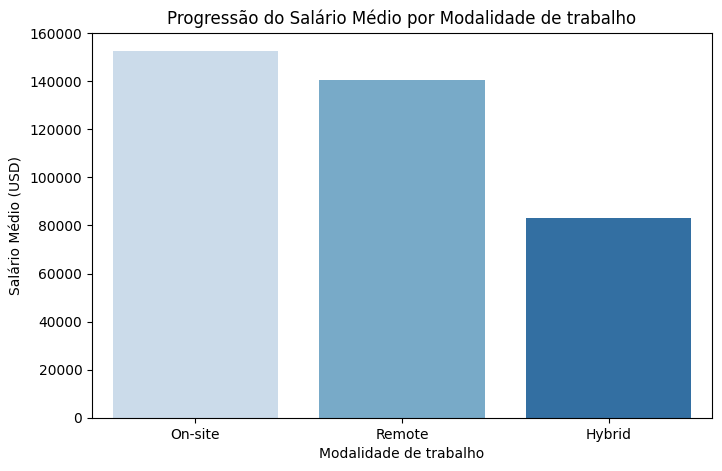

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_modalidade, x="modalidade_trabalho", y="salario_usd", palette="Blues")
plt.title("Progressão do Salário Médio por Modalidade de trabalho")
plt.xlabel("Modalidade de trabalho")
plt.ylabel("Salário Médio (USD)")
plt.show()

Conforme apresentação da média salarial por tipo de trabalho constata-se que o presencial tem média superior ao remoto, que por sua vez tem média salarial superior ao trabalho híbrido.

In [13]:
df_mod_nivel = (
    df.groupby(["modalidade_trabalho", "nivel_experiencia"])["salario_usd"]
      .mean()
      .reset_index()
)

df_mod_nivel.round(2)

,modalidade_trabalho,nivel_experiencia,salario_usd
0,Hybrid,Entry-level,63998.44
1,Hybrid,Executive-level,147368.67
2,Hybrid,Mid-level,76990.86
3,Hybrid,Senior-level,106145.92
4,On-site,Entry-level,96933.89
5,On-site,Executive-level,185061.71
6,On-site,Mid-level,129770.81
7,On-site,Senior-level,166657.46
8,Remote,Entry-level,75154.08
9,Remote,Executive-level,198580.90


In [14]:
ordem_niveis = ["Entry-level", "Mid-level", "Senior-level", "Executive-level"]

df_mod_nivel["nivel_experiencia"] = pd.Categorical(
    df_mod_nivel["nivel_experiencia"],
    categories=ordem_niveis,
    ordered=True
)

df_mod_nivel = df_mod_nivel.sort_values(["modalidade_trabalho", "nivel_experiencia"]).round(2)
df_mod_nivel

,modalidade_trabalho,nivel_experiencia,salario_usd
0,Hybrid,Entry-level,63998.44
2,Hybrid,Mid-level,76990.86
3,Hybrid,Senior-level,106145.92
1,Hybrid,Executive-level,147368.67
4,On-site,Entry-level,96933.89
6,On-site,Mid-level,129770.81
7,On-site,Senior-level,166657.46
5,On-site,Executive-level,185061.71
8,Remote,Entry-level,75154.08
10,Remote,Mid-level,107083.53


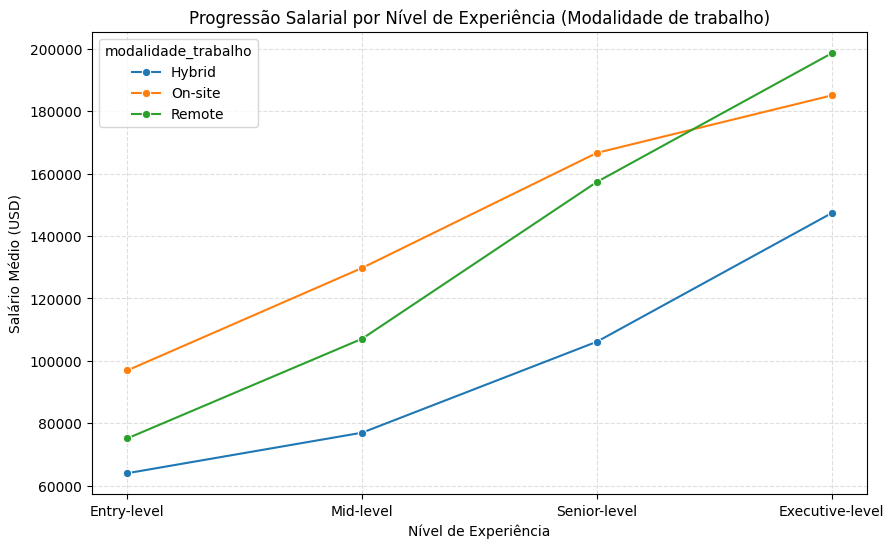

In [16]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_mod_nivel,
    x="nivel_experiencia",
    y="salario_usd",
    hue="modalidade_trabalho",
    marker="o"
)

plt.title("Progressão Salarial por Nível de Experiência (Modalidade de trabalho)")
plt.xlabel("Nível de Experiência")
plt.ylabel("Salário Médio (USD)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Para os niveis Entry, Mid e Senior, a resposta é a mesma da analise anterior, o trabalho presencial tem a média salarial maior, porem para o cargo Executive, a modalidade remote tem média salarial superior as demais modalidades.

## Pergunta 4 – Comparativo entre cargos de dados

Comparem Data Analyst, Data Scientist, Data Engineer e Machine Learning Engineer (ou similares no dataset): qual paga mais, qual tem mais vagas, qual tem maior crescimento ao longo dos anos?

Vamos comparar Data Analyst, Data Scientist, Data Engineer e Machine Learning Engineer em três dimensões: salário médio, quantidade de vagas e evolução salarial ao longo dos anos.

In [17]:
cargos_alvo = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer",
    "Machine Learning Engineer"
]

df_cargos = filtrar_por_cargos(df, cargos_alvo)

df_cargos.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade_trabalho,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
8,Data Engineer,Executive-level,Full-time,Remote,2024,United States,219650,USD,219650,United States,Medium


In [18]:
df_salario_cargo = (
    df_cargos.groupby("cargo")["salario_usd"]
             .mean()
             .reset_index()
             .sort_values("salario_usd", ascending=False)
)

df_salario_cargo.round(2)

,cargo,salario_usd
3,Machine Learning Engineer,177226.45
2,Data Scientist,149036.65
1,Data Engineer,144539.70
0,Data Analyst,106931.69


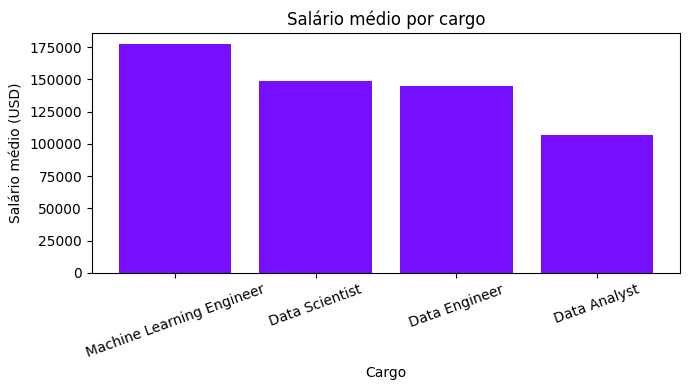

In [19]:
plt.figure(figsize=(7,4))
plt.bar(df_salario_cargo["cargo"], df_salario_cargo["salario_usd"], color="#760eff")
plt.title("Salário médio por cargo")
plt.xlabel("Cargo")
plt.ylabel("Salário médio (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Machine Learning Engineer possui a média salarial maior do que as demais funções.

In [20]:
df_vagas = vagas_por_cargo(df_cargos)
df_vagas

,cargo,qtd_vagas
0,Data Engineer,1307
1,Data Scientist,1243
2,Data Analyst,910
3,Machine Learning Engineer,629


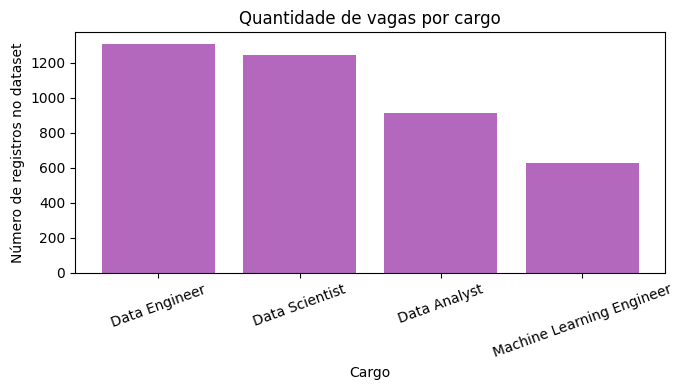

In [21]:
plt.figure(figsize=(7,4))
plt.bar(df_vagas["cargo"], df_vagas["qtd_vagas"], color="#b367bd")
plt.title("Quantidade de vagas por cargo")
plt.xlabel("Cargo")
plt.ylabel("Número de registros no dataset")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

O cargo Data Engineer possui o maior numero de vagas.

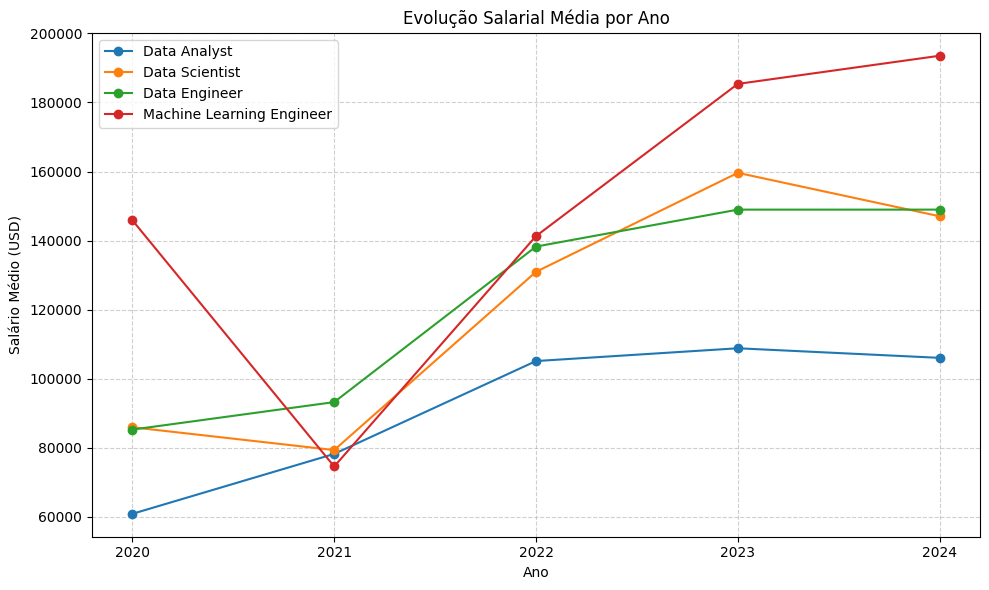

In [22]:
# Agrupando por ano e cargo para ver a evolução
df_evolucao = (
    df_cargos.groupby(['ano', 'cargo'])['salario_usd']
             .mean()
             .reset_index()
)

plt.figure(figsize=(10, 6))
for cargo in cargos_alvo:
    subset = df_evolucao[df_evolucao['cargo'] == cargo]
    plt.plot(subset['ano'], subset['salario_usd'], marker='o', label=cargo)

plt.title('Evolução Salarial Média por Ano')
plt.xlabel('Ano')
plt.ylabel('Salário Médio (USD)')
plt.xticks(df_evolucao['ano'].unique())
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

O maior crescimento salarial ao longo os anos foi da função Machine Learning Engineer.